• Loaded raw datasets and standardised column names, data types, and formats  
• Removed duplicate booking and restaurant records to avoid double-counting  
• Filtered booking data to keep only completed and realised transactions  
• Excluded cancelled, refunded, no-show, inactive, system-generated, and future-dated records  
• Dropped columns with excessive missing values and removed rows with missing critical identifiers  
• Identified and removed extreme outliers according to identified restaurant_id in gsheet  
• Converted revenue values from cents to dollars for consistency  
• Merged booking-level data with restaurant metadata using restaurant_id , used geolocation api to retrieve countries and information about restaurant
• Aggregated booking-level data to restaurant-level performance metrics  
• Created time features (year, month) from booking dates  
• Engineered growth, trend, and rolling metrics for momentum analysis  


In [1]:
# If you have yet installed the libraries
# !{sys.executable} -m pip install pyarrow fastparquet


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = Path.cwd().parent  
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"

bookings = pd.read_parquet(PARQUET_PATH / "bookings.parquet")
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
cuisine = pd.read_parquet(PARQUET_PATH / "cuisine.parquet")
ratings = pd.read_parquet(PARQUET_PATH / "ratings.parquet")
channels = pd.read_parquet(PARQUET_PATH / "channels.parquet")


In [3]:
bookings.isnull().sum() 

id                           0
restaurant_id                0
date                         0
start_time                   0
end_time                     0
adult                        0
kids                         0
user_id_masked               0
guest_id_masked        3267512
medium                 2562347
channel                      0
arrived                      0
no_show                      0
for_locking_system           0
is_temporary                 0
active                       0
has_special_request    2582512
created_at                   0
ack                          0
cancelled_by           3167337
adjusted                     0
refund                       1
confirmed_by           3266089
prepared                     0
revenue                      0
has_promptpay          3172193
has_cc                 3109817
has_shopee_pay         2588914
has_alipay             3264530
has_wechat_pay         3265440
has_true_wallet        3267992
dtype: int64

In [4]:
bookings['active'].unique()

array([ True, False])

In [5]:
valid_bookings = bookings.copy()

In [6]:
#This section documents how Hungry Hub filters their data for Gross Merchandise Value (GMV) calculations, e.g. no_show, refund, and revenue, and the list continues.
#I presume there should be more restrictions that we have to set, so please add accordingly. 

#i think with this new dataset, some of the fields have changed data types, we may need to edit the code separately. for now, i will create valid_bookings_df as a copy of bookings
# valid_bookings = bookings[
#     (bookings['revenue'] > 0) &
#     (bookings["no_show"] == False) &
#     (bookings["refund"] == 'False') &
#     (bookings['active'] == True) &
#     (bookings['ack'] == True) &
#     (bookings['is_temporary'] == False) &
#     (bookings['for_locking_system'] == True) &
#     (bookings['channel'] != 5)
# ]
# valid_bookings.head()

In [7]:
valid_bookings.describe()

,id,restaurant_id,adult,kids,guest_id_masked,channel,has_special_request,revenue,has_promptpay,has_cc,has_shopee_pay,has_alipay,has_wechat_pay,has_true_wallet
count,3.267992e+06,3.267992e+06,3.267992e+06,3.267992e+06,4.800000e+02,3.267992e+06,685480.000000,3.267992e+06,95799.0,158175.0,679078.0,3462.0,2552.0,0.0
mean,6.195581e+06,3.113601e+03,2.868470e+00,1.003528e-01,9.049160e+18,1.836904e+02,0.138907,3.757548e+04,1.0,1.0,0.0,1.0,1.0,NaN
std,1.255942e+06,1.610956e+03,2.281271e+00,1.389173e+01,5.198629e+18,1.096734e+03,0.345850,8.319358e+04,0.0,0.0,0.0,0.0,0.0,NaN
min,8.657320e+05,3.300000e+01,0.000000e+00,-1.000000e+00,3.748906e+16,0.000000e+00,0.000000,1.000000e+01,1.0,1.0,0.0,1.0,1.0,NaN
25%,5.159982e+06,1.561000e+03,2.000000e+00,0.000000e+00,4.748193e+18,0.000000e+00,0.000000,1.558800e+04,1.0,1.0,0.0,1.0,1.0,NaN
50%,6.142960e+06,3.618000e+03,2.000000e+00,0.000000e+00,8.829972e+18,0.000000e+00,0.000000,2.900000e+04,1.0,1.0,0.0,1.0,1.0,NaN
75%,7.163924e+06,4.503000e+03,3.000000e+00,0.000000e+00,1.330975e+19,0.000000e+00,0.000000,4.360000e+04,1.0,1.0,0.0,1.0,1.0,NaN
max,8.865629e+06,6.945000e+03,8.000000e+02,2.301000e+04,1.839172e+19,9.020000e+03,1.000000,1.148299e+08,1.0,1.0,0.0,1.0,1.0,NaN


Find high missing columns: removes if > 95%

In [8]:
# Calculate missing data percentage for each column
missing_stats = pd.DataFrame({
    'column': valid_bookings.columns,
    'missing_count': valid_bookings.isnull().sum(),
    'missing_percentage': (valid_bookings.isnull().sum() / len(valid_bookings)) * 100
})

# Sort by missing percentage
missing_stats = missing_stats.sort_values('missing_percentage', ascending=False)

print("\nMissing Data Summary:")
print(missing_stats)

# Filter columns with less than 95% missing data
good_columns = missing_stats[missing_stats['missing_percentage'] < 99]['column'].tolist()

print(f"\n{len(good_columns)} columns have < 99% missing data")
print(f"{len(valid_bookings.columns) - len(good_columns)} columns will be dropped")

# Create filtered dataframe
valid_bookings_df = valid_bookings[good_columns]


Missing Data Summary:
                                  column  missing_count  missing_percentage
has_true_wallet          has_true_wallet        3267992          100.000000
guest_id_masked          guest_id_masked        3267512           99.985312
confirmed_by                confirmed_by        3266089           99.941769
has_wechat_pay            has_wechat_pay        3265440           99.921909
has_alipay                    has_alipay        3264530           99.894063
has_promptpay              has_promptpay        3172193           97.068567
cancelled_by                cancelled_by        3167337           96.919974
has_cc                            has_cc        3109817           95.159872
has_shopee_pay            has_shopee_pay        2588914           79.220329
has_special_request  has_special_request        2582512           79.024428
medium                            medium        2562347           78.407383
refund                            refund              1          

* Change denomination to Dollars
* Convert to booking date, start_time, end_time to datetime
* added day of week

In [9]:
#To convert current Revenue (denominated in cents) into dollars
valid_bookings_df['revenue_dollars'] = (valid_bookings_df['revenue']/100).round(2)
valid_bookings_df.drop(columns=['revenue'], inplace=True)

# Convert date and time columns to appropriate formats
valid_bookings_df['booking_date'] = pd.to_datetime(valid_bookings_df['date'], errors='coerce')
valid_bookings_df['start_time'] = pd.to_datetime(valid_bookings_df['start_time'], format="%H:%M", errors='coerce').dt.time
valid_bookings_df['end_time'] = pd.to_datetime(valid_bookings_df['end_time'], format="%H:%M", errors='coerce').dt.time
valid_bookings_df.drop(columns=['date'], inplace=True)
# Add weekday number (0=Monday, 6=Sunday)
valid_bookings_df['day_of_week_index'] = pd.to_datetime(valid_bookings_df['booking_date']).dt.weekday

# Add weekday name
valid_bookings_df['day_of_week'] = pd.to_datetime(valid_bookings_df['booking_date']).dt.day_name()

C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\2777764728.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_bookings_df['revenue_dollars'] = (valid_bookings_df['revenue']/100).round(2)
C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\2777764728.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_bookings_df.drop(columns=['revenue'], inplace=True)
C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\2777764728.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [10]:
#clear instance where a single user has multiple transactions recorded on the same date, with different revenue amounts. 
#clarified with Hungry Hub team that the duplicates exist because of the way they refresh and update their data, they mentioned can check a particular column (refer to google spreadsheet) but 
#they have yet to provide us with the column so for now we can't do much about it. 

valid_bookings_df.loc[valid_bookings_df['id'] == 8716589]

,has_promptpay,cancelled_by,has_cc,has_shopee_pay,has_special_request,medium,refund,created_at,prepared,adjusted,...,user_id_masked,kids,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week
3182824,NaN,<NA>,NaN,0.0,1.0,Web,False,2025-12-16T05:34:03,False,False,...,,0,10,20:00:00,19:00:00,True,999.0,2025-12-23,1,Tuesday
3182825,NaN,<NA>,NaN,0.0,1.0,Web,False,2025-12-16T05:34:03,False,False,...,,0,10,20:00:00,19:00:00,True,1071.5,2025-12-23,1,Tuesday
3182826,NaN,<NA>,NaN,0.0,1.0,Web,False,2025-12-16T05:34:03,False,False,...,,0,10,20:00:00,19:00:00,True,1098.9,2025-12-23,1,Tuesday


* removes if kids less than 0 or more than 100
* removes if adults less than 0 or more than 1000
* removes if revenue > 10000

In [11]:
# Define custom outlier conditions -- to determine our outliers based on Hungry Hub's requests/negative values/extreme values
valid_bookings_df['is_outlier'] = False
valid_bookings_df['outlier_reason'] = ''

# Kids outliers: < 0 or > 100
kids_outliers = (valid_bookings_df['kids'] < 0) | (valid_bookings_df['kids'] > 100)
valid_bookings_df.loc[kids_outliers, 'is_outlier'] = True
valid_bookings_df.loc[kids_outliers, 'outlier_reason'] += 'kids_invalid; '

# Adults outliers: < 0 or > 1000
adults_outliers = (valid_bookings_df['adult'] < 0) | (valid_bookings_df['adult'] > 1000)
valid_bookings_df.loc[adults_outliers, 'is_outlier'] = True
valid_bookings_df.loc[adults_outliers, 'outlier_reason'] += 'adults_invalid; '

# Revenue outliers: > 10000
revenue_outliers = valid_bookings_df['revenue_dollars'] > 10000
valid_bookings_df.loc[revenue_outliers, 'is_outlier'] = True
valid_bookings_df.loc[revenue_outliers, 'outlier_reason'] += 'revenue_high; '

# Summary
print("="*60)
print("OUTLIER DETECTION SUMMARY")
print("="*60)
print(f"Total records: {len(valid_bookings_df):,}")
print(f"Total outliers: {valid_bookings_df['is_outlier'].sum():,} ({valid_bookings_df['is_outlier'].sum()/len(valid_bookings_df)*100:.2f}%)")
print()

# Breakdown by type
print("Outlier breakdown:")
print(f"  Kids outliers (< 0 or > 100): {kids_outliers.sum():,}")
print(f"  Adults outliers (< 0 or > 1000): {adults_outliers.sum():,}")
print(f"  Revenue outliers (> $10000): {revenue_outliers.sum():,}")
print()

# Detailed statistics
outliers_df = valid_bookings_df[valid_bookings_df['is_outlier'] == True]

print("="*60)
print("KIDS OUTLIERS")
print("="*60)
kids_out = valid_bookings_df[kids_outliers]
if len(kids_out) > 0:
    print(f"Negative kids: {(kids_out['kids'] < 0).sum()}")
    print(f"Kids > 10: {(kids_out['kids'] > 10).sum()}")
    print(f"Max kids value: {kids_out['kids'].max()}")
    print(f"Min kids value: {kids_out['kids'].min()}")
    print("\nSample:")
    print(kids_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('kids', ascending=False).head(10))

print ()

OUTLIER DETECTION SUMMARY
Total records: 3,267,992
Total outliers: 78 (0.00%)

Outlier breakdown:
  Kids outliers (< 0 or > 100): 4
  Adults outliers (< 0 or > 1000): 0
  Revenue outliers (> $10000): 76

KIDS OUTLIERS
Negative kids: 1
Kids > 10: 3
Max kids value: 23010
Min kids value: -1

Sample:
              id booking_date   kids  adult  revenue_dollars
587850   4870618   2024-05-19  23010      1        1148298.8
2893858  7840206   2025-08-26  10000      9         647990.0
392856   4575452   2024-04-03    120      1           6087.8
3124387  8401289   2025-12-10     -1      2            233.2



C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\409366426.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_bookings_df['is_outlier'] = False
C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\409366426.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_bookings_df['outlier_reason'] = ''


In [12]:
print()
print("="*60)
print("ADULTS OUTLIERS")
print("="*60)
adults_out = valid_bookings_df[adults_outliers]
if len(adults_out) > 0:
    print(f"Negative adults: {(adults_out['adult'] < 0).sum()}")
    print(f"Adults > 50: {(adults_out['adult'] > 45).sum()}")
    print(f"Max adults value: {adults_out['adult'].max()}")
    print(f"Min adults value: {adults_out['adult'].min()}")
    print("\nSample:")
    print(adults_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('adult', ascending=True).head(10))


ADULTS OUTLIERS


In [13]:
print()
print("="*60)
print("REVENUE OUTLIERS")
print("="*60)
revenue_out = valid_bookings_df[revenue_outliers]
if len(revenue_out) > 0:
    print(f"Count: {len(revenue_out):,}")
    print(f"Max revenue: ${revenue_out['revenue_dollars'].max():,.2f}")
    print(f"Mean of outliers: ${revenue_out['revenue_dollars'].mean():,.2f}")
    print(f"Median of outliers: ${revenue_out['revenue_dollars'].median():,.2f}")
    print("\nTop 10 by revenue:")
    print(revenue_out[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars']].sort_values('revenue_dollars', ascending=False).head(10))

# View all outliers sorted
print()
print("="*60)
print("ALL OUTLIERS (Top 10)")
print("="*60)
print(outliers_df[['id', 'booking_date', 'kids', 'adult', 'revenue_dollars', 'outlier_reason']].head(10))


REVENUE OUTLIERS
Count: 76
Max revenue: $1,148,298.80
Mean of outliers: $39,810.68
Median of outliers: $14,436.24

Top 10 by revenue:
              id booking_date   kids  adult  revenue_dollars
587850   4870618   2024-05-19  23010      1       1148298.80
2893858  7840206   2025-08-26  10000      9        647990.00
2757697  7564665   2025-06-14      0      2         41205.60
1963965  6587686   2024-12-22      0    200         39000.00
989111   5370143   2024-07-28      0     10         34500.00
2361167  7063062   2025-02-06      1    174         32209.88
554922   4806531   2024-07-03      0    300         29940.00
1963961  6587680   2024-12-22      0    150         29250.00
2681678  7450727   2025-05-24      0    300         28620.00
26473    4084512   2024-03-01      0      2         26997.00

ALL OUTLIERS (Top 10)
             id booking_date  kids  adult  revenue_dollars  outlier_reason
7749    4039726   2024-01-19     0     46         10110.80  revenue_high; 
26473   4084512   202

In [14]:
valid_bookings_df.head()

,has_promptpay,cancelled_by,has_cc,has_shopee_pay,has_special_request,medium,refund,created_at,prepared,adjusted,...,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
0,NaN,<NA>,NaN,0.0,0.0,iOS,<NA>,2021-08-05T04:40:02,True,False,...,7,17:00:00,15:00:00,True,553.00,2025-12-01,0,Monday,False,
1,NaN,admin,NaN,0.0,0.0,Web,False,2022-11-01T08:28:57,False,False,...,2,18:00:00,16:00:00,False,79.20,2024-10-31,3,Thursday,False,
2,NaN,admin,NaN,0.0,1.0,Web,False,2022-11-01T08:29:29,False,False,...,2,20:00:00,18:00:00,False,79.20,2024-10-31,3,Thursday,False,
3,NaN,<NA>,NaN,NaN,NaN,<NA>,False,2023-08-13T05:47:00.000000,False,False,...,1,19:00:00,19:00:00,True,149.93,2025-05-13,1,Tuesday,False,
4,NaN,<NA>,1.0,0.0,0.0,Web,False,2023-08-24T12:38:03,False,False,...,2,19:00:00,19:00:00,True,302.25,2024-06-17,0,Monday,False,


In [15]:
valid_bookings_df.to_parquet("valid_bookings.parquet")

* aggregate restaurant level

In [16]:
#Start of restaurant-level aggregation, feature engineering right now currently includes just the aggregation of numeric features. 
#One possible enhancement is to include categorical features

from scipy import stats
from sklearn.preprocessing import StandardScaler

# Create total_guests if not exists
if 'total_guests' not in valid_bookings_df.columns:
    valid_bookings_df['total_guests'] = valid_bookings_df['adult'] + valid_bookings_df['kids']

# Create revenue_per_guest if not exists
if 'revenue_per_guest' not in valid_bookings_df.columns:
    valid_bookings_df['revenue_per_guest'] = (valid_bookings_df['revenue_dollars'] / valid_bookings_df['total_guests']).replace([np.inf, -np.inf], 0).fillna(0).round(2)

# restaurant-level aggregation
restaurant_agg = valid_bookings_df.groupby('restaurant_id').agg({
    'id': 'count',
    'revenue_dollars': ['sum', 'mean', 'median', 'std', 'min', 'max'],
    'adult': ['sum', 'mean', 'median'],
    'kids': ['sum', 'mean', 'median'],
    'total_guests': ['sum', 'mean', 'median', 'std'],
    'revenue_per_guest': ['mean', 'median', 'std'],
    'booking_date': ['min', 'max', 'nunique'],
    'day_of_week': lambda x: x.mode()[0] if len(x.mode()) > 0 else None,  # Most common day
    'start_time': ['min', 'max']
}).round(2)

# Flatten column names
restaurant_agg.columns = ['_'.join(col).strip() for col in restaurant_agg.columns.values]
restaurant_agg = restaurant_agg.reset_index()

In [17]:
import numpy as np
import pandas as pd

# -----------------------------
# 0) Ensure categorical columns exist + are clean
# -----------------------------
categorical_cols = [
    "medium",
    "arrived",
    "has_special_request",
    "has_promptpay",
    "has_cc",
    "has_shopee_pay",
    "has_alipay",
    "has_wechat_pay",
    "has_true_wallet",
]

# Keep only cols that actually exist (prevents KeyError)
categorical_cols = [c for c in categorical_cols if c in valid_bookings_df.columns]

# Optional: standardize booleans to True/False (helps OHE consistency)
bool_like = [c for c in categorical_cols if c != "medium"]
for c in bool_like:
    valid_bookings_df[c] = valid_bookings_df[c].astype("bool", errors="ignore")

# Optional: fill missing medium as "unknown" so it gets its own bucket
if "medium" in categorical_cols:
    valid_bookings_df["medium"] = valid_bookings_df["medium"].fillna("unknown").astype(str)

# -----------------------------
# 1) One-hot encode booking-level categorical vars
# -----------------------------
group_var = "restaurant_id"

bookings_ohe = pd.get_dummies(
    valid_bookings_df[[group_var] + categorical_cols].copy(),
    columns=categorical_cols,
    prefix=categorical_cols,
    prefix_sep="__",
    dummy_na=False,
)

# Grab ONLY the dummy columns we created
dummy_cols = [c for c in bookings_ohe.columns if c != group_var]

# -----------------------------
# 2) Aggregate dummies per restaurant: mean + sum
#    - mean => "share of bookings with that attribute"
#    - sum  => "count of bookings with that attribute"
# -----------------------------
cat_grouped = bookings_ohe.groupby(group_var)[dummy_cols].agg(["mean", "sum"])

# Flatten columns into <dummy>_count_norm and <dummy>_count
cat_grouped.columns = [
    f"{col}_count_norm" if stat == "mean" else f"{col}_count"
    for col, stat in cat_grouped.columns
]
cat_grouped = cat_grouped.reset_index()

# -----------------------------
# 3) Merge into your restaurant_agg
# -----------------------------
restaurant_agg = restaurant_agg.merge(
    cat_grouped,
    on="restaurant_id",
    how="left",
)

# If a restaurant somehow has no rows in cat_grouped, fill 0 for those dummy aggregations
new_cat_cols = [c for c in restaurant_agg.columns if c.endswith("_count") or c.endswith("_count_norm")]
restaurant_agg[new_cat_cols] = restaurant_agg[new_cat_cols].fillna(0)

restaurant_agg.head()


,restaurant_id,id_count,revenue_dollars_sum,revenue_dollars_mean,revenue_dollars_median,revenue_dollars_std,revenue_dollars_min,revenue_dollars_max,adult_sum,adult_mean,...,has_special_request__True_count_norm,has_special_request__True_count,has_promptpay__True_count_norm,has_promptpay__True_count,has_cc__True_count_norm,has_cc__True_count,has_shopee_pay__False_count_norm,has_shopee_pay__False_count,has_shopee_pay__True_count_norm,has_shopee_pay__True_count
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,0.758484,6482,1.0,8546,1.0,8546,0.279195,2386,0.720805,6160
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,0.709184,139,1.0,196,1.0,196,0.428571,84,0.571429,112
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,0.585987,184,1.0,314,1.0,314,0.585987,184,0.414013,130
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,0.674847,220,1.0,326,1.0,326,0.463190,151,0.536810,175
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,0.745455,7872,1.0,10560,1.0,10560,0.306534,3237,0.693466,7323


In [18]:
restaurant_agg = restaurant_agg.merge(restaurants, left_on='restaurant_id', right_on='restaurant_id', how='left')
restaurant_agg.head()

,restaurant_id,id_count,revenue_dollars_sum,revenue_dollars_mean,revenue_dollars_median,revenue_dollars_std,revenue_dollars_min,revenue_dollars_max,adult_sum,adult_mean,...,has_promptpay__True_count_norm,has_promptpay__True_count,has_cc__True_count_norm,has_cc__True_count,has_shopee_pay__False_count_norm,has_shopee_pay__False_count,has_shopee_pay__True_count_norm,has_shopee_pay__True_count,name,days_in_advance
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,1.0,8546,1.0,8546,0.279195,2386,0.720805,6160,Audrey Cafe Thonglor Soi 11,90.0
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,1.0,196,1.0,196,0.428571,84,0.571429,112,<NA>,NaN
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,1.0,314,1.0,314,0.585987,184,0.414013,130,Attico Cucina Italiana Radisson Blu Plaza Bangkok,60.0
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,1.0,326,1.0,326,0.463190,151,0.536810,175,The Living Room at Sheraton Grande Sukhumvit A...,30.0
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,1.0,10560,1.0,10560,0.306534,3237,0.693466,7323,Rain Tree Cafe at The Athenee Hotel,90.0


In [19]:
restaurant_agg.columns
# Rename for clarity need to update now that there are more columns
rename_dict = {
    'id_count': 'total_bookings',
    'revenue_dollars_sum': 'total_revenue',
    'revenue_dollars_mean': 'avg_revenue_per_booking',
    'revenue_dollars_median': 'median_revenue_per_booking',
    'revenue_dollars_std': 'revenue_std',
    'revenue_dollars_min': 'min_revenue',
    'revenue_dollars_max': 'max_revenue',
    'adult_sum': 'total_adults',
    'adult_mean': 'avg_adults',
    'adult_median': 'median_adults',
    'kids_sum': 'total_kids',
    'kids_mean': 'avg_kids',
    'kids_median': 'median_kids',
    'total_guests_sum': 'total_guests_sum',
    'total_guests_mean': 'avg_party_size',
    'total_guests_median': 'median_party_size',
    'total_guests_std': 'party_size_std',
    'revenue_per_guest_mean': 'avg_revenue_per_guest',
    'revenue_per_guest_median': 'median_revenue_per_guest',
    'revenue_per_guest_std': 'revenue_per_guest_std',
    'booking_date_min': 'first_booking',
    'booking_date_max': 'last_booking',
    'booking_date_nunique': 'unique_booking_days',
    'day_of_week_<lambda>': 'most_popular_day_of_week',
    'start_time_min': 'earliest_booking_time',
    'start_time_max': 'latest_booking_time'
    
}

restaurant_agg.rename(columns=rename_dict, inplace=True)

restaurant_agg.head()

,restaurant_id,total_bookings,total_revenue,avg_revenue_per_booking,median_revenue_per_booking,revenue_std,min_revenue,max_revenue,total_adults,avg_adults,...,has_promptpay__True_count_norm,has_promptpay__True_count,has_cc__True_count_norm,has_cc__True_count,has_shopee_pay__False_count_norm,has_shopee_pay__False_count,has_shopee_pay__True_count_norm,has_shopee_pay__True_count,name,days_in_advance
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,1.0,8546,1.0,8546,0.279195,2386,0.720805,6160,Audrey Cafe Thonglor Soi 11,90.0
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,1.0,196,1.0,196,0.428571,84,0.571429,112,<NA>,NaN
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,1.0,314,1.0,314,0.585987,184,0.414013,130,Attico Cucina Italiana Radisson Blu Plaza Bangkok,60.0
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,1.0,326,1.0,326,0.463190,151,0.536810,175,The Living Room at Sheraton Grande Sukhumvit A...,30.0
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,1.0,10560,1.0,10560,0.306534,3237,0.693466,7323,Rain Tree Cafe at The Athenee Hotel,90.0


In [20]:
import pandas as pd
import re

def extract_city_robust(row):
    address = str(row.get('formatted_address', ''))
    country = str(row.get('country', ''))
    
    # 1. Handle Singapore (City-State)
    if 'Singapore' in country or 'Singapore' in address:
        return 'Singapore'
        
    # 2. Handle Hong Kong
    if 'Hong Kong' in country or 'Hong Kong' in address:
        return 'Hong Kong'

    # 3. Handle Thailand
    # Detect Bangkok (Standard English, Thai, or Formal Name)
    if re.search(r'Krung Thep Maha Nakhon|Bangkok|กรุงเทพมหานคร', address, re.IGNORECASE):
        return 'Bangkok'
    
    # Detect Thai Provinces (Format: "Chang Wat [Name]")
    match_changwat = re.search(r'Chang Wat\s+([a-zA-Z\s]+?)(?=\s\d|,|$)', address, re.IGNORECASE)
    if match_changwat:
        return match_changwat.group(1).strip()
    
    # 4. Handle USA (Format: "City, State Zip")
    # Captures the text before the State Abbreviation (2 caps) and Zip (5 digits)
    if 'United States' in country or 'USA' in address:
        match_us = re.search(r',\s*([^,]+?),\s*[A-Z]{2}\s+\d{5}', address)
        if match_us:
            return match_us.group(1).strip()

    # 5. Fallback Heuristic (Word before Zip Code)
    # Useful for non-standard formats; grabs the last significant text block before the 5-digit zip
    match_zip = re.search(r',\s*([a-zA-Z\s]+?)\s+\d{5}', address)
    if match_zip:
        return match_zip.group(1).strip()

    return "" # Leave blank if undetermined

# Load the file
google_restaurants_df = pd.read_csv('places_api_new_results.csv')

# Apply the extraction
google_restaurants_df['city'] = google_restaurants_df.apply(extract_city_robust, axis=1)

# # Save the cleaned file
# output_filename = 'cleaned_places_results.csv'
# google_restaurants_df.to_csv(output_filename, index=False)

# print(f"Success! '{output_filename}' has been created.")
# print(google_restaurants_df[['formatted_address', 'city']].head(10)) # Preview

In [21]:
# restaurant_agg = restaurant_agg.merge(restaurants, left_on='restaurant_id', right_on='restaurant_id', how='left')
# restaurant_agg.head()
# restaurants_merged_valid_bookings = restaurant_agg.merge(
#     google_restaurants_df, on='name', how='left')
# restaurants_merged_valid_bookings.head()

C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\1873265596.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x='Count', y='City', palette='viridis')


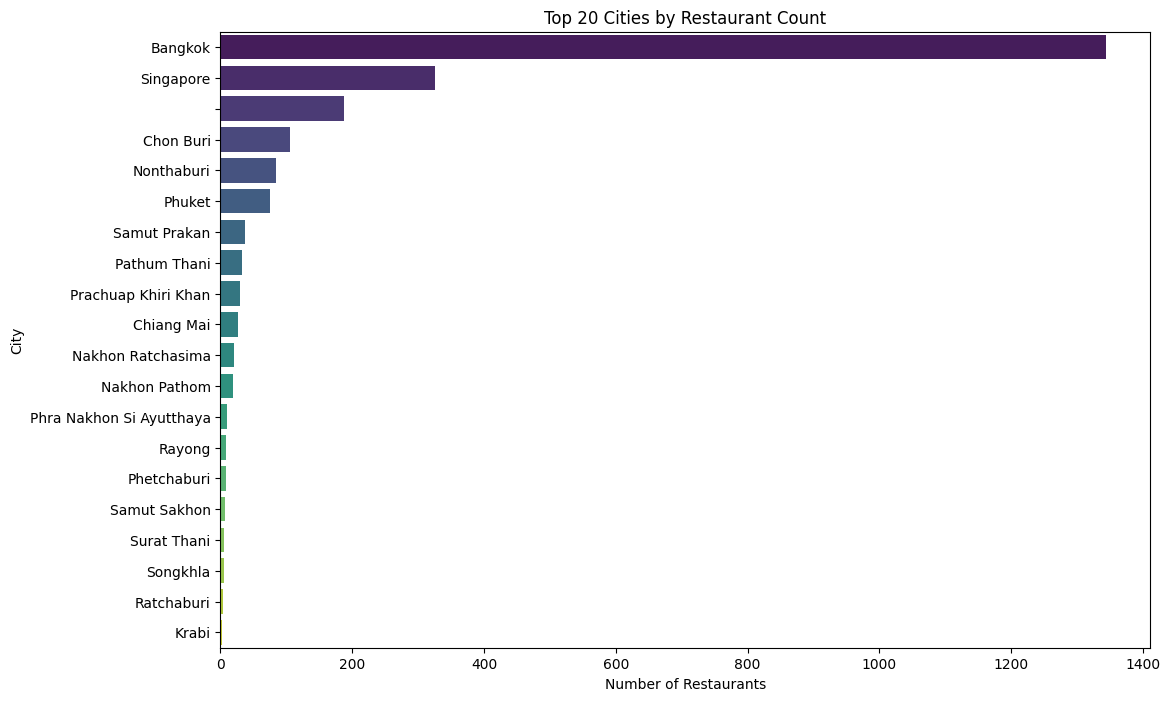

C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\1873265596.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_counts.head(10), x='Count', y='Country', palette='magma')


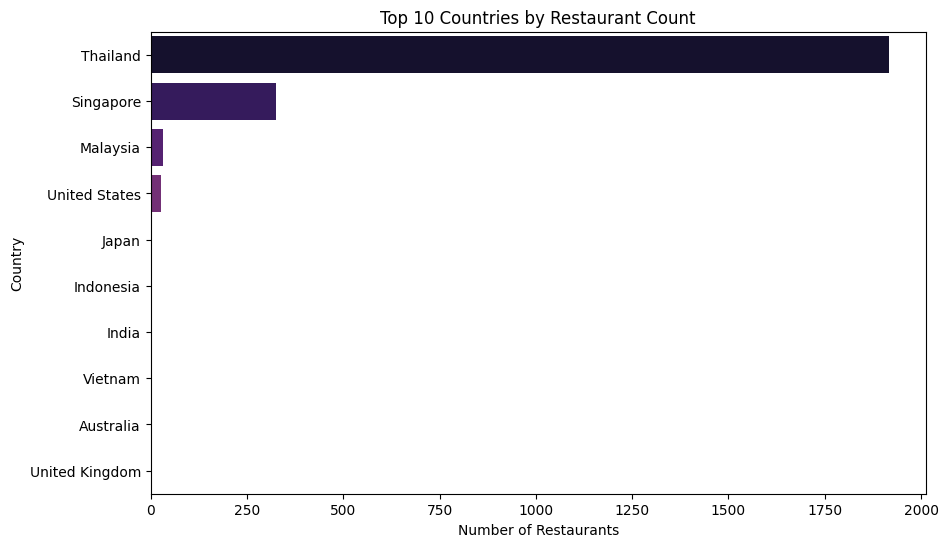

In [22]:
google_restaurants_df[google_restaurants_df['country'] == 'Thailand']['city'].value_counts()
#generate plots for unique cities distribution for restaurants
import matplotlib.pyplot as plt
import seaborn as sns
# --- Plot 1: Top 20 Cities ---
city_counts = google_restaurants_df['city'].value_counts().head(20).reset_index()
city_counts.columns = ['City', 'Count']

plt.figure(figsize=(12, 8))
sns.barplot(data=city_counts, x='Count', y='City', palette='viridis')
plt.title('Top 20 Cities by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.show()

# --- Plot 2: Country Distribution ---
country_counts = google_restaurants_df['country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=country_counts.head(10), x='Count', y='Country', palette='magma')
plt.title('Top 10 Countries by Restaurant Count')
plt.xlabel('Number of Restaurants')
plt.show()

C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\4134175921.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=ax, palette='viridis')
C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\4134175921.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=ax, palette='viridis')
C:\Users\foogu\AppData\Local\Temp\ipykernel_21340\4134175921.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=ax, palette='viridis')
C:\U

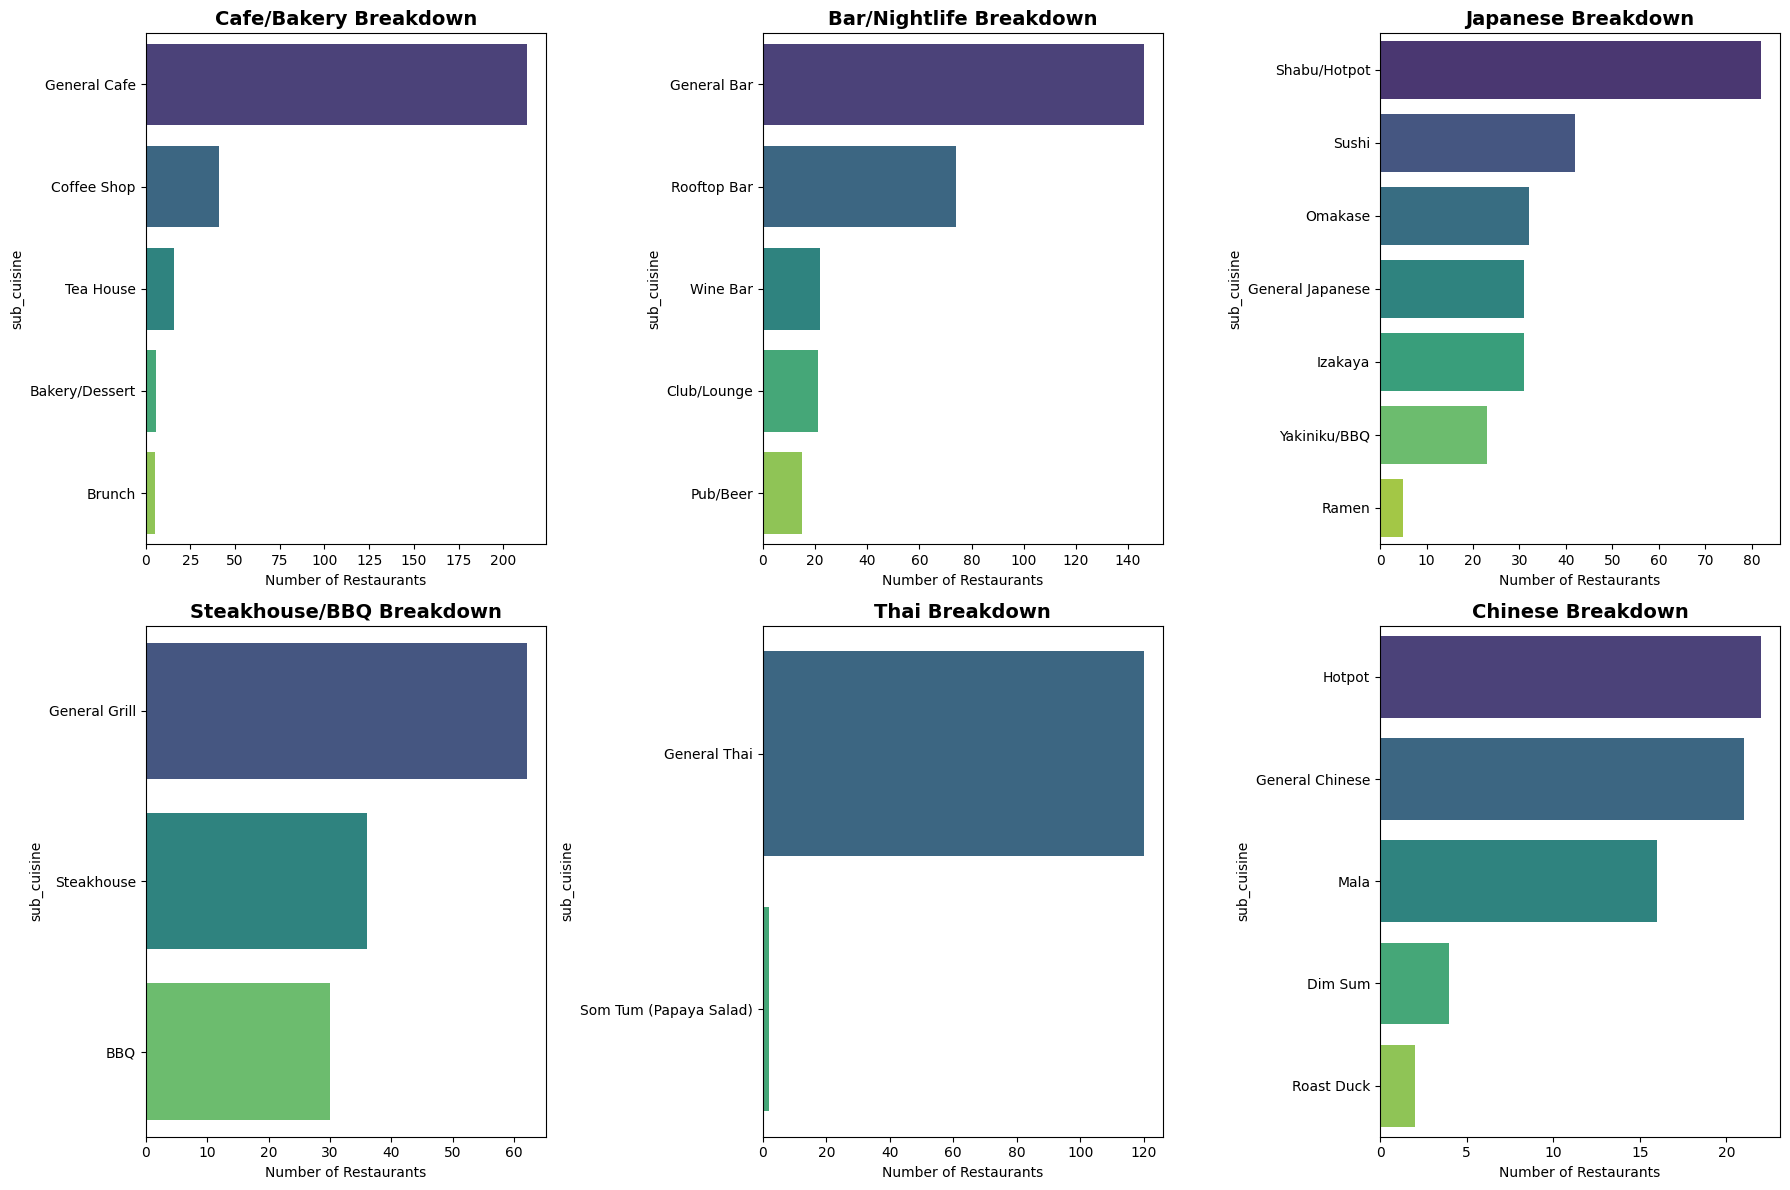

In [23]:
# 2. Define the Hierarchy Extraction Logic
def extract_cuisine_hierarchy(row):
    # Combine 'official_name' and 'input_string' for maximum context
    text = (str(row.get('official_name', '')) + " " + str(row.get('input_string', ''))).lower()
    
    major = 'Uncategorized'
    sub = 'General'

    # --- JAPANESE ---
    if re.search(r'japanese|sushi|ramen|izakaya|omakase|yakiniku|tempura|udon|soba|donburi|teppanyaki|shabu|sukiyaki', text):
        major = 'Japanese'
        if 'sushi' in text: sub = 'Sushi'
        elif 'ramen' in text: sub = 'Ramen'
        elif 'omakase' in text: sub = 'Omakase'
        elif 'izakaya' in text: sub = 'Izakaya'
        elif 'yakiniku' in text or 'bbq' in text: sub = 'Yakiniku/BBQ'
        elif 'shabu' in text or 'sukiyaki' in text or 'nabe' in text: sub = 'Shabu/Hotpot'
        elif 'tempura' in text: sub = 'Tempura'
        else: sub = 'General Japanese'

    # --- CHINESE ---
    elif re.search(r'chinese|dim sum|hotpot|mala|hong kong|duck|cantonese|shabu', text):
        major = 'Chinese'
        if 'dim sum' in text: sub = 'Dim Sum'
        elif 'mala' in text: sub = 'Mala'
        elif 'hotpot' in text: sub = 'Hotpot'
        elif 'duck' in text: sub = 'Roast Duck'
        else: sub = 'General Chinese'

    # --- ITALIAN ---
    elif re.search(r'italian|pizza|pasta|cucina|ristorante|spaghetti', text):
        major = 'Italian'
        if 'pizza' in text: sub = 'Pizza'
        elif 'pasta' in text or 'spaghetti' in text: sub = 'Pasta'
        else: sub = 'General Italian'
        
    # --- STEAKHOUSE / BBQ ---
    elif re.search(r'steak|grill|meat|beef|bbq|ribs|wagyu', text):
        major = 'Steakhouse/BBQ'
        if 'steak' in text or 'wagyu' in text or 'beef' in text: sub = 'Steakhouse'
        elif 'bbq' in text or 'ribs' in text: sub = 'BBQ'
        else: sub = 'General Grill'
        
    # --- CAFE / BAKERY ---
    elif re.search(r'cafe|café|coffee|bakery|dessert|cake|tea|brunch|bistro|pastry', text):
        major = 'Cafe/Bakery'
        if 'coffee' in text or 'roast' in text: sub = 'Coffee Shop'
        elif 'bakery' in text or 'pastry' in text or 'cake' in text: sub = 'Bakery/Dessert'
        elif 'tea' in text: sub = 'Tea House'
        elif 'brunch' in text: sub = 'Brunch'
        else: sub = 'General Cafe'
        
    # --- BAR / NIGHTLIFE ---
    elif re.search(r'bar|pub|lounge|club|rooftop|beer|wine|cocktail', text):
        major = 'Bar/Nightlife'
        if 'rooftop' in text or 'sky' in text: sub = 'Rooftop Bar'
        elif 'wine' in text: sub = 'Wine Bar'
        elif 'pub' in text or 'beer' in text: sub = 'Pub/Beer'
        elif 'club' in text: sub = 'Club/Lounge'
        else: sub = 'General Bar'
        
    # --- SEAFOOD ---
    elif re.search(r'seafood|crab|fish|lobster|oyster|shrimp', text):
        major = 'Seafood'
        if 'crab' in text: sub = 'Crab Specialist'
        elif 'oyster' in text: sub = 'Oyster Bar'
        else: sub = 'General Seafood'
        
    # --- THAI ---
    elif re.search(r'thai|siam|nara|som tum|tomyum|baan', text):
        major = 'Thai'
        if 'som tum' in text: sub = 'Som Tum (Papaya Salad)'
        elif 'boat noodle' in text: sub = 'Boat Noodles'
        else: sub = 'General Thai'
    
    return pd.Series([major, sub], index=['major_cuisine', 'sub_cuisine'])

# 3. Apply Function & Save
google_restaurants_df[['major_cuisine', 'sub_cuisine']] = google_restaurants_df.apply(extract_cuisine_hierarchy, axis=1)

# 4. Generate Visualizations (Subplots)
# Filter data to remove 'Uncategorized' and focus on Top 6 Major Cuisines
breakdown = google_restaurants_df[google_restaurants_df['major_cuisine'] != 'Uncategorized'].copy()
top_majors = breakdown['major_cuisine'].value_counts().head(6).index
# filtered_data = breakdown[breakdown['major_cuisine'].isin(top_majors)]

# Initialize Subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Loop through top 6 cuisines and plot their sub-types
for i, cuisine in enumerate(top_majors):
    ax = axes[i]
    subset = breakdown[breakdown['major_cuisine'] == cuisine]
    sub_counts = subset['sub_cuisine'].value_counts()
    
    sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=ax, palette='viridis')
    ax.set_title(f'{cuisine} Breakdown', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Restaurants')
    
plt.tight_layout()
plt.show()

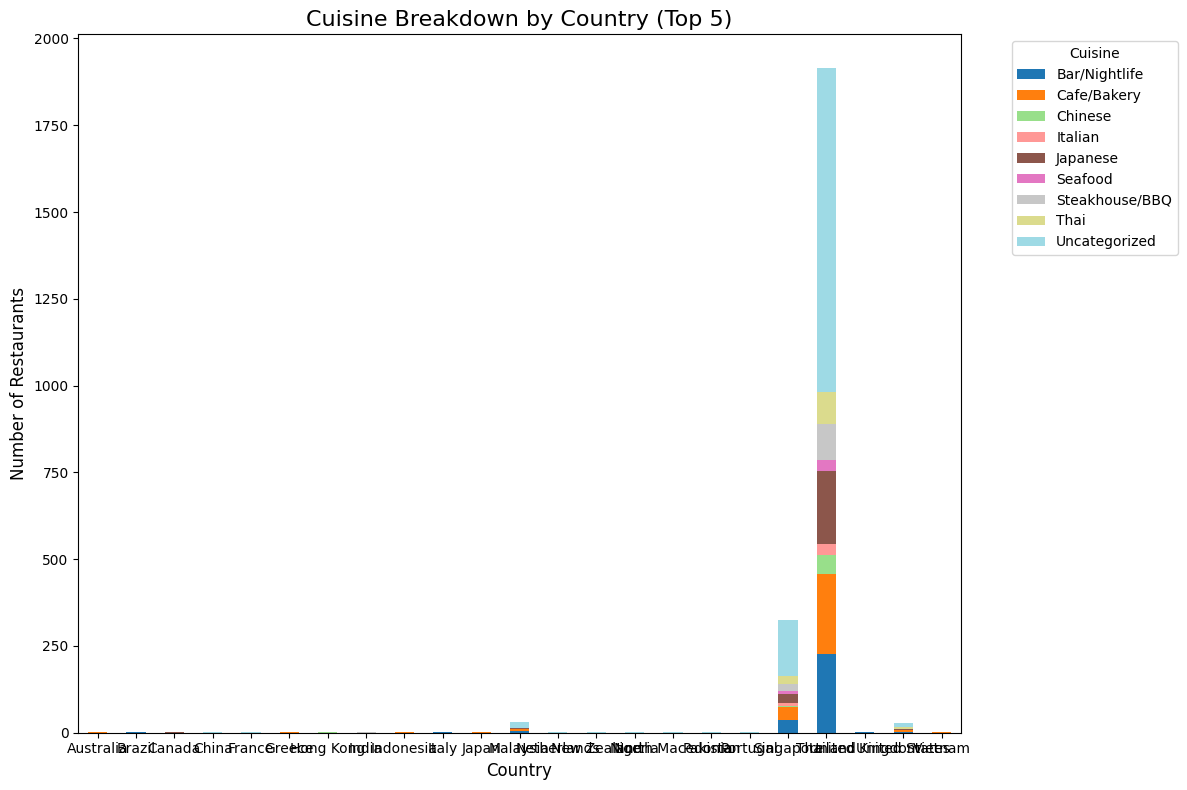

In [24]:
# Visualisation of cuisine breakdown by country (includes uncategorised restaurants)
cuisine_counts = pd.crosstab(google_restaurants_df['country'], google_restaurants_df['major_cuisine'])

# 5. Generate Stacked Bar Chart
ax = cuisine_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title('Cuisine Breakdown by Country (Top 5)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.legend(title='Cuisine', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

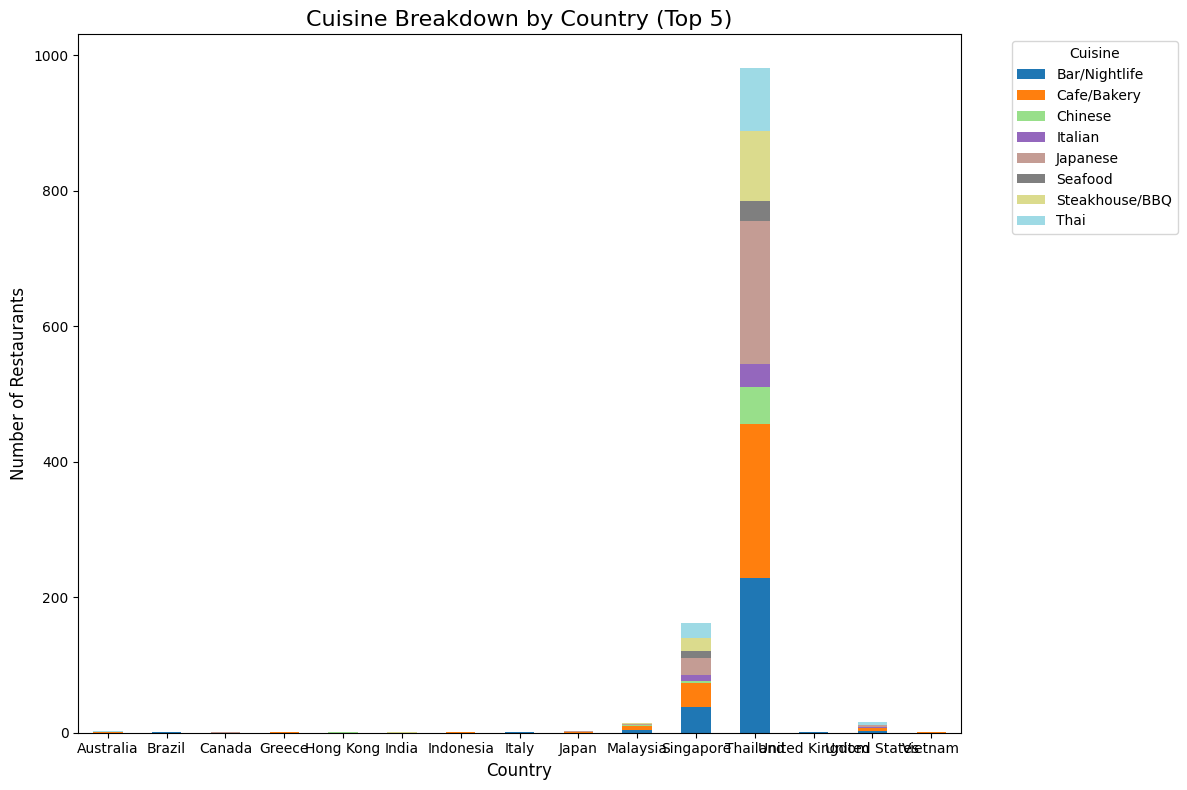

In [25]:
# Visualisation of cuisine breakdown by country -- includes categorised restaurants
cuisine_counts = pd.crosstab(breakdown['country'], breakdown['major_cuisine'])

# 5. Generate Stacked Bar Chart
ax = cuisine_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title('Cuisine Breakdown by Country (Top 5)', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.legend(title='Cuisine', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
restaurant_agg.head()

,restaurant_id,total_bookings,total_revenue,avg_revenue_per_booking,median_revenue_per_booking,revenue_std,min_revenue,max_revenue,total_adults,avg_adults,...,has_promptpay__True_count_norm,has_promptpay__True_count,has_cc__True_count_norm,has_cc__True_count,has_shopee_pay__False_count_norm,has_shopee_pay__False_count,has_shopee_pay__True_count_norm,has_shopee_pay__True_count,name,days_in_advance
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,1.0,8546,1.0,8546,0.279195,2386,0.720805,6160,Audrey Cafe Thonglor Soi 11,90.0
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,1.0,196,1.0,196,0.428571,84,0.571429,112,<NA>,NaN
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,1.0,314,1.0,314,0.585987,184,0.414013,130,Attico Cucina Italiana Radisson Blu Plaza Bangkok,60.0
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,1.0,326,1.0,326,0.463190,151,0.536810,175,The Living Room at Sheraton Grande Sukhumvit A...,30.0
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,1.0,10560,1.0,10560,0.306534,3237,0.693466,7323,Rain Tree Cafe at The Athenee Hotel,90.0


In [27]:
restaurant_agg = restaurant_agg.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
restaurant_agg.head()

,restaurant_id,total_bookings,total_revenue,avg_revenue_per_booking,median_revenue_per_booking,revenue_std,min_revenue,max_revenue,total_adults,avg_adults,...,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,major_cuisine,sub_cuisine
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,Thailand,"Soi Thong Lo 11, Khwaeng Khlong Tan Nuea, Watt...",4.2,http://www.audreygroup.com/,API key not valid. Please pass a valid API key.,Cafe,0.60,"restaurant,wedding_venue,event_venue,cafe,poin...",Cafe/Bakery,General Cafe
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,Thailand,"489 Sukhumvit Rd, Khwaeng Khlong Toei Nuea, Wa...",4.5,https://www.radissonhotels.com/en-us/hotels/ra...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",Italian,General Italian
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,Thailand,"250 Sukhumvit Rd, Khwaeng Khlong Toei, Khet Kh...",4.7,https://www.marriott.com/en-us/hotels/bkklc-sh...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment",Uncategorized,General
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,Thailand,"61 Thanon Witthayu, Khwaeng Lumphini, Pathum W...",4.4,https://www.raintreecafebangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int...",Cafe/Bakery,General Cafe


In [28]:
import requests

# 1. Define your mapping from Country Name to Currency Code
country_to_currency = {
    'Thailand': 'THB',
    'Singapore': 'SGD',
    'Malaysia': 'MYR',
    'United States': 'USD',
    'Japan': 'JPY',
    'Hong Kong': 'HKD',
    'United Kingdom': 'GBP',
    'Australia': 'AUD',
    'Vietnam': 'VND',
    'Indonesia': 'IDR',
    'India': 'INR',
    'France': 'EUR',
    'Italy': 'EUR',
    'Netherlands': 'EUR'
}

# 2. Function to get LIVE rates (Free, No Key Required)
def get_live_rates(base_currency='USD'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception as e:
        print(f"API Error: {e}")
    
    # FALLBACK: If API fails, use these approximate rates (retrieved Feb 2026)
    print("Using fallback rates...")
    return {
        'THB': 0.0316, 'SGD': 0.787, 'MYR': 0.254, 
        'JPY': 0.0064, 'USD': 1.0, 'EUR': 1.08, 
        'GBP': 1.25, 'AUD': 0.65, 'HKD': 0.13,
        'VND': 0.000041, 'IDR': 0.000064, 'INR': 0.012
    }

# 3. Get the rates
exchange_rates_to_usd = get_live_rates('USD')

# 4. Apply conversion to your dataframe
def convert_to_usd(row):
    country = row.get('country') # Ensure this matches your column name
    amount = row.get('total_revenue') # Ensure this matches your column name
    
    # Lookup currency code
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        # Get rate: (Target / Source) -> But since our rates are "Amount of USD per 1 Unit", 
        # we verify the math logic.
        # The API returns rates relative to base (e.g. 1 USD = 31 THB).
        # So to get USD from THB, we DIVIDE by the rate (Amount / Rate).
        # Wait! open.er-api returns "1 USD = X Currency".
        # So: 1000 THB / 31.6 (Rate) = 31.6 USD.
        
        rate = exchange_rates_to_usd.get(currency_code)
        if rate:
            return amount / rate
            
    return amount # Or return amount if already USD

# Apply it
restaurant_agg['total_revenue_usd'] = restaurant_agg.apply(convert_to_usd, axis=1)

print(restaurant_agg[['country', 'total_revenue', 'total_revenue_usd']].head())

    country  total_revenue  total_revenue_usd
0  Thailand     1909944.62       60317.264748
1       NaN       52627.80       52627.800000
2  Thailand       83182.80        2626.965681
3  Thailand      185774.20        5866.867284
4  Thailand     5459723.62      172421.541227


In [29]:
restaurant_agg.head()

,restaurant_id,total_bookings,total_revenue,avg_revenue_per_booking,median_revenue_per_booking,revenue_std,min_revenue,max_revenue,total_adults,avg_adults,...,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,major_cuisine,sub_cuisine,total_revenue_usd
0,33,8546,1909944.62,223.49,114.4,268.61,7.20,7052.0,30346,3.55,...,"Soi Thong Lo 11, Khwaeng Khlong Tan Nuea, Watt...",4.2,http://www.audreygroup.com/,API key not valid. Please pass a valid API key.,Cafe,0.60,"restaurant,wedding_venue,event_venue,cafe,poin...",Cafe/Bakery,General Cafe,60317.264748
1,34,196,52627.80,268.51,229.0,182.07,169.00,1436.0,530,2.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52627.800000
2,168,314,83182.80,264.91,199.8,189.98,99.00,1298.7,798,2.54,...,"489 Sukhumvit Rd, Khwaeng Khlong Toei Nuea, Wa...",4.5,https://www.radissonhotels.com/en-us/hotels/ra...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",Italian,General Italian,2626.965681
3,220,326,185774.20,569.86,690.9,380.52,192.60,2072.7,1128,3.46,...,"250 Sukhumvit Rd, Khwaeng Khlong Toei, Khet Kh...",4.7,https://www.marriott.com/en-us/hotels/bkklc-sh...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment",Uncategorized,General,5866.867284
4,222,10560,5459723.62,517.02,370.8,483.19,79.68,12236.4,48400,4.58,...,"61 Thanon Witthayu, Khwaeng Lumphini, Pathum W...",4.4,https://www.raintreecafebangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int...",Cafe/Bakery,General Cafe,172421.541227


In [30]:
# 1. Setup the Exchange Rates (1 USD = X Local Currency)
# (Using the rates we established earlier)
rates = {
    'THB': 31.6, 'SGD': 1.34, 'MYR': 4.43, 'JPY': 150.0, 
    'USD': 1.0, 'EUR': 0.92, 'GBP': 0.79, 'AUD': 1.53, 
    'HKD': 7.82, 'VND': 24500, 'IDR': 15600, 'INR': 83.0
}

# 2. Setup Country Mapping
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR', 
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 3. List of columns that need conversion
# (Excluding 'total_revenue_usd' since it is already done)
revenue_cols = [
    'avg_revenue_per_booking', 
    'median_revenue_per_booking', 
    'revenue_std', 
    'min_revenue', 
    'max_revenue', 
    'avg_revenue_per_guest', 
    'median_revenue_per_guest', 
    'revenue_per_guest_std'
]

# 4. Create a Series of rates aligned with your DataFrame
# This looks up the currency for each row's country, then gets the rate
# resulting in a column of rates matching the rows
aligned_rates = restaurant_agg['country'].map(country_to_currency).map(rates)

# 5. Loop and Convert
for col in revenue_cols:
    if col in restaurant_agg.columns:
        # Create a new column name, e.g., 'avg_revenue_per_booking_usd'
        new_col_name = f"{col}_usd"
        
        # Apply conversion: Local Value / Rate = USD Value
        restaurant_agg[new_col_name] = restaurant_agg[col] / aligned_rates

# Check the results
print(restaurant_agg[[c + '_usd' for c in revenue_cols]].head())

   avg_revenue_per_booking_usd  median_revenue_per_booking_usd  \
0                     7.072468                        3.620253   
1                          NaN                             NaN   
2                     8.383228                        6.322785   
3                    18.033544                       21.863924   
4                    16.361392                       11.734177   

   revenue_std_usd  min_revenue_usd  max_revenue_usd  \
0         8.500316         0.227848       223.164557   
1              NaN              NaN              NaN   
2         6.012025         3.132911        41.098101   
3        12.041772         6.094937        65.591772   
4        15.290823         2.521519       387.227848   

   avg_revenue_per_guest_usd  median_revenue_per_guest_usd  \
0                   1.807278                      1.724684   
1                        NaN                           NaN   
2                   3.374367                      3.161392   
3                 

In [31]:
# 1. Define the list of original (old) columns you want to remove
cols_to_drop = [
    'total_revenue', 
    'avg_revenue_per_booking', 
    'median_revenue_per_booking', 
    'revenue_std', 
    'min_revenue', 
    'max_revenue', 
    'avg_revenue_per_guest', 
    'median_revenue_per_guest', 
    'revenue_per_guest_std'
]

# 2. Drop them from the dataframe
# errors='ignore' ensures the code doesn't crash if you accidentally run it twice (and the cols are already gone)
restaurant_agg.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [33]:
# Add cuisine from Places results
places_df = pd.read_csv("places_api_new_results.csv")

In [35]:

places_cuisine = places_df[["input_string", "Cuisine", "Cuisine_confidence"]].drop_duplicates()

if "input_string" in restaurant_agg.columns:
    restaurant_agg = restaurant_agg.merge(places_cuisine, on="input_string", how="left")
elif "name" in restaurant_agg.columns:
    restaurant_agg = restaurant_agg.merge(
        places_cuisine,
        left_on="name",
        right_on="input_string",
        how="left"
    )
    restaurant_agg.drop(columns=["input_string"], inplace=True)
else:
    print("Warning: no join key (input_string or name) found in restaurant_agg")

restaurant_agg.head()

,restaurant_id,total_bookings,total_adults,avg_adults,median_adults,total_kids,avg_kids,median_kids,total_guests_sum,avg_party_size,...,avg_revenue_per_booking_usd,median_revenue_per_booking_usd,revenue_std_usd,min_revenue_usd,max_revenue_usd,avg_revenue_per_guest_usd,median_revenue_per_guest_usd,revenue_per_guest_std_usd,Cuisine_y,Cuisine_confidence_y
0,33,8546,30346,3.55,2.0,798,0.09,0.0,31144,3.64,...,7.072468,3.620253,8.500316,0.227848,223.164557,1.807278,1.724684,0.733228,Cafe,0.60
1,34,196,530,2.70,2.0,0,0.00,0.0,530,2.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,168,314,798,2.54,2.0,1,0.00,0.0,799,2.54,...,8.383228,6.322785,6.012025,3.132911,41.098101,3.374367,3.161392,1.139241,Italian,0.70
3,220,326,1128,3.46,4.0,12,0.04,0.0,1140,3.50,...,18.033544,21.863924,12.041772,6.094937,65.591772,4.916139,5.465823,1.709810,NaN,0.20
4,222,10560,48400,4.58,4.0,879,0.08,0.0,49279,4.67,...,16.361392,11.734177,15.290823,2.521519,387.227848,3.803797,3.151899,1.201899,General,0.15
